# Visualización: FIFA World Cup

Este notebook invoca la clase `Visualizador` para generar las gráficas clave que responden preguntas sobre los partidos de la FIFA World Cup, a partir del dataset ya procesado.

## Preparación: cargar el dataset ya procesado.

In [9]:
import sys
sys.path.append("../src")

import pandas as pd

from ingesta.cargador_datos import CargadorDatos
from eda.procesador_eda import ProcesadorEDA
from gestor.gestor_partidos import GestorPartidos
from visualizacion.visualizador import Visualizador

cargador = CargadorDatos(url_origen="https://raw.githubusercontent.com/martj42/international_results/master/results.csv", ruta_raw="../data/raw/partidos-mundial.csv", ruta_processed="../data/processed/partidos-mundial-procesado.csv",)
df_procesado = cargador.cargar_procesado()

gestor = GestorPartidos(df_procesado)
procesador = ProcesadorEDA(df_procesado)
visualizador = Visualizador(df_procesado, carpeta_salida="../reports/figures")

df_procesado.head()

,id_partido,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,anio,total_goles,diferencia_goles,ganador
0,1,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-3,Visitante
1,2,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True,1930,5,3,Local
2,3,1930-07-14,Brazil,Yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-1,Visitante
3,4,1930-07-14,Peru,Romania,1,3,FIFA World Cup,Montevideo,Uruguay,True,1930,4,-2,Visitante
4,5,1930-07-15,Argentina,France,1,0,FIFA World Cup,Montevideo,Uruguay,True,1930,1,1,Local


## 1. ¿En qué Mundial se metieron más goles por partido?

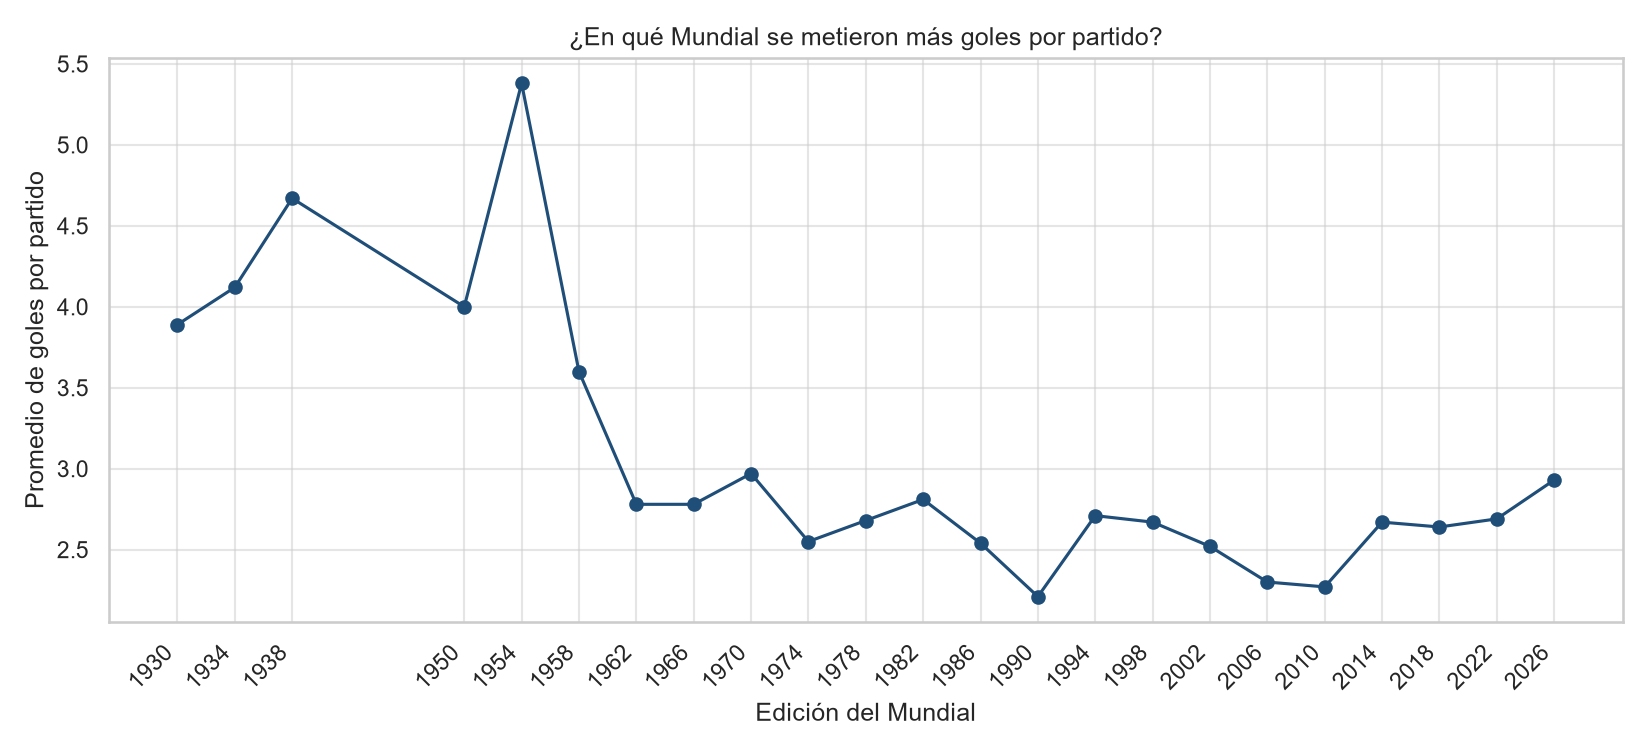

In [10]:
tabla_promedio = procesador.promedio_goles_por_edicion()
visualizador.goles_promedio_por_edicion(tabla_promedio)

from IPython.display import Image
Image("../reports/figures/goles_promedio_por_edicion.png")

El promedio de goles por mundial se analiza desde la primera edición en 1930, pasando por un espacio sin la competición debido a los conflictos de la Segunda Guerra Munidial.

Tuvo su punto máximo en 1954 y desde entonces muestra una tendencia decreciente con altibajos hasta las ediciones modernas.

## 2. ¿El país sede gana más?

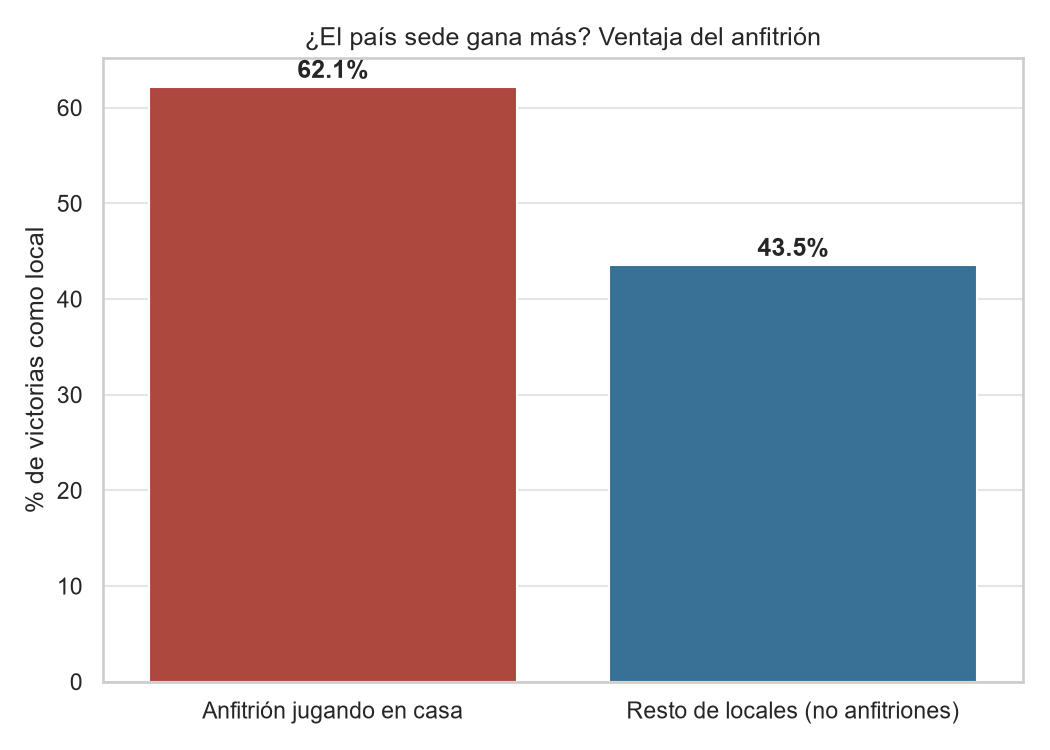

In [11]:
tabla_sede = procesador.desempeno_pais_sede()
visualizador.ventaja_pais_anfitrion(tabla_sede)

Image("../reports/figures/ventaja_pais_anfitrion.png")

Los equipos que juegan como país anfitrión ganan un porcentaje
de partidos claramente superior (62%) a diferencia del resto de locales (43.5%).
Lo que sugiere una ventaja real de jugar en casa frente a la propia afición.

## 3. ¿Qué selección tiene la mejor diferencia de goles histórica?

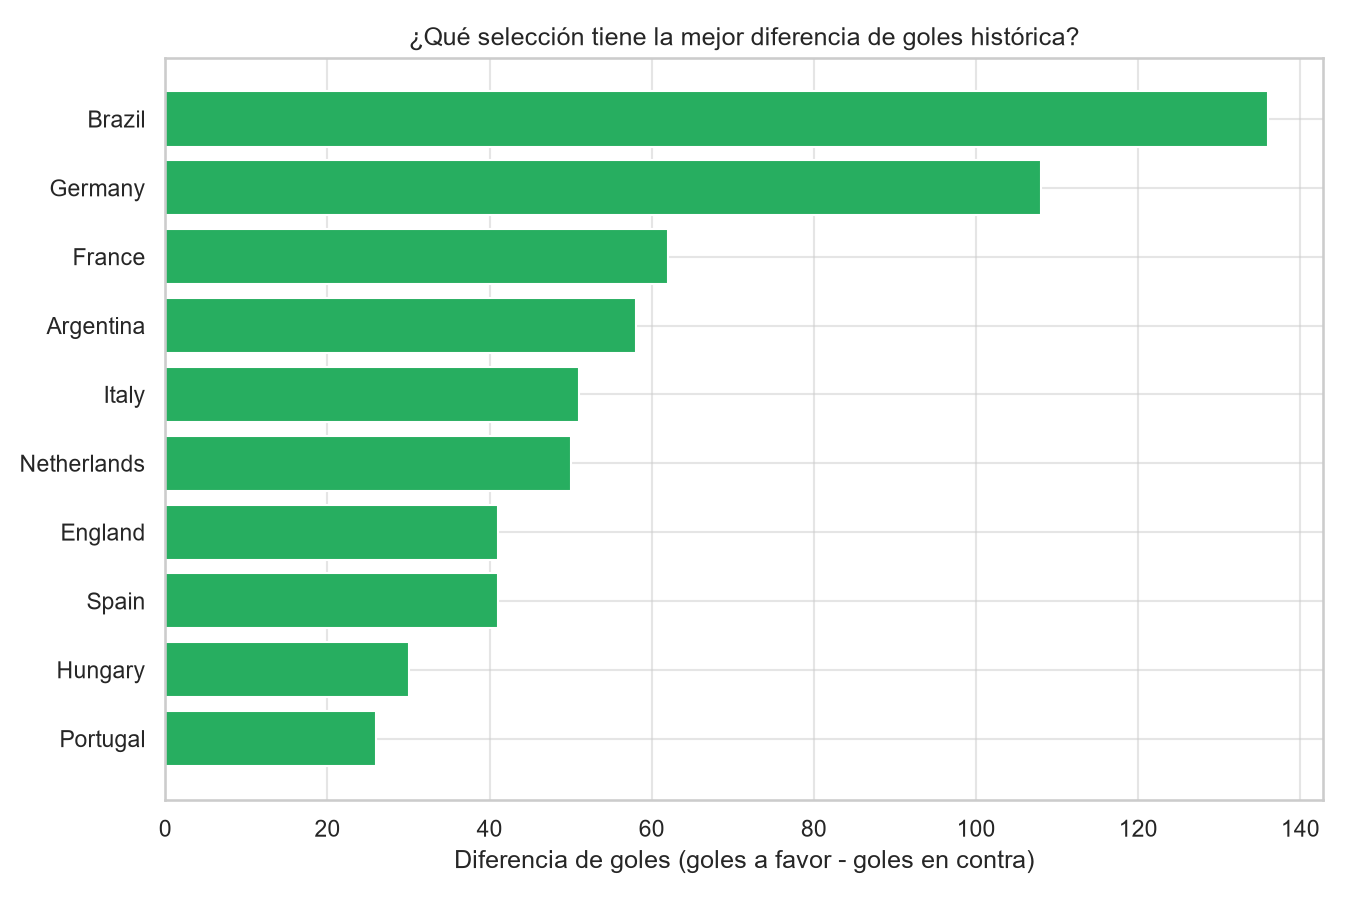

In [12]:
tabla_diferencia = gestor.tabla_diferencia_goles(top_n=10)
visualizador.top_diferencia_goles(tabla_diferencia)

Image("../reports/figures/top_diferencia_goles.png")

En este caso, Brasil y Alemania encabezan claramente el ranking histórico
de diferencia de goles en Copas del Mundo.

## 4. Distribución de goles por partido

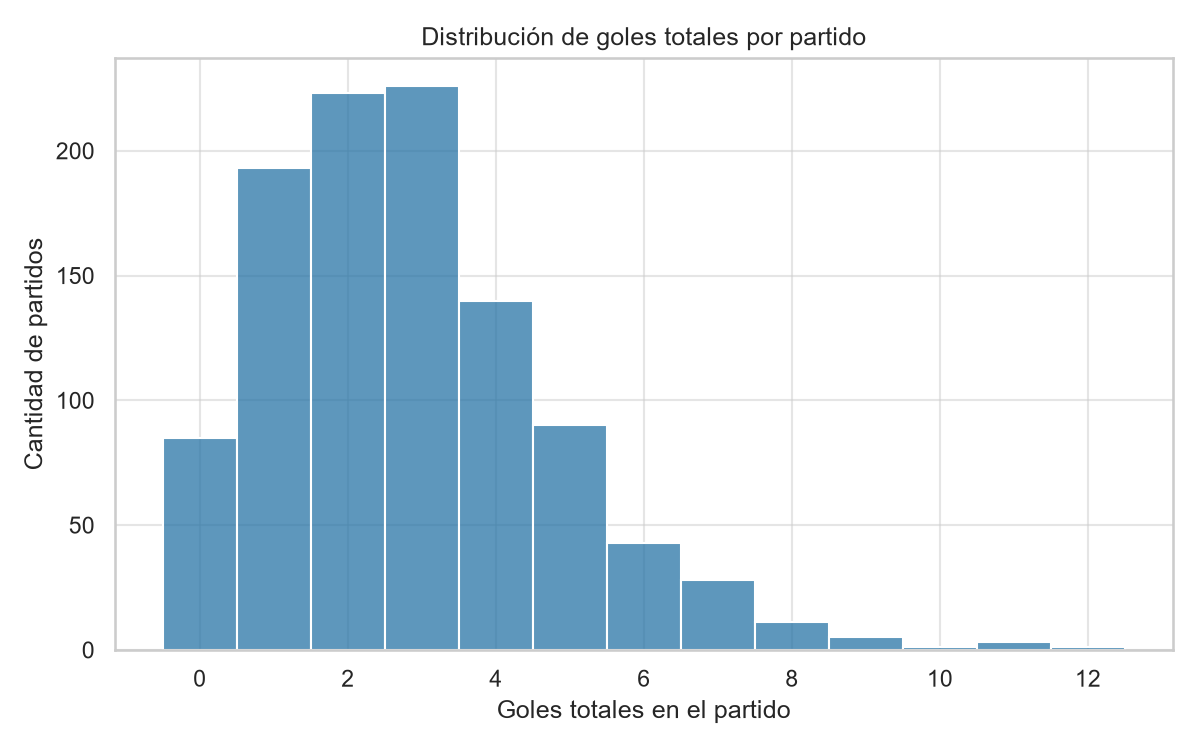

In [13]:
visualizador.distribucion_goles_partido()

Image("../reports/figures/distribucion_goles_partido.png")

En este histograma se puede ver que la mayoría de partidos tienen entre 2 y 3 goles totales,
con una cola larga hacia goleadas poco comunes (8 o más goles).

## 5. Matriz de correlación entre variables

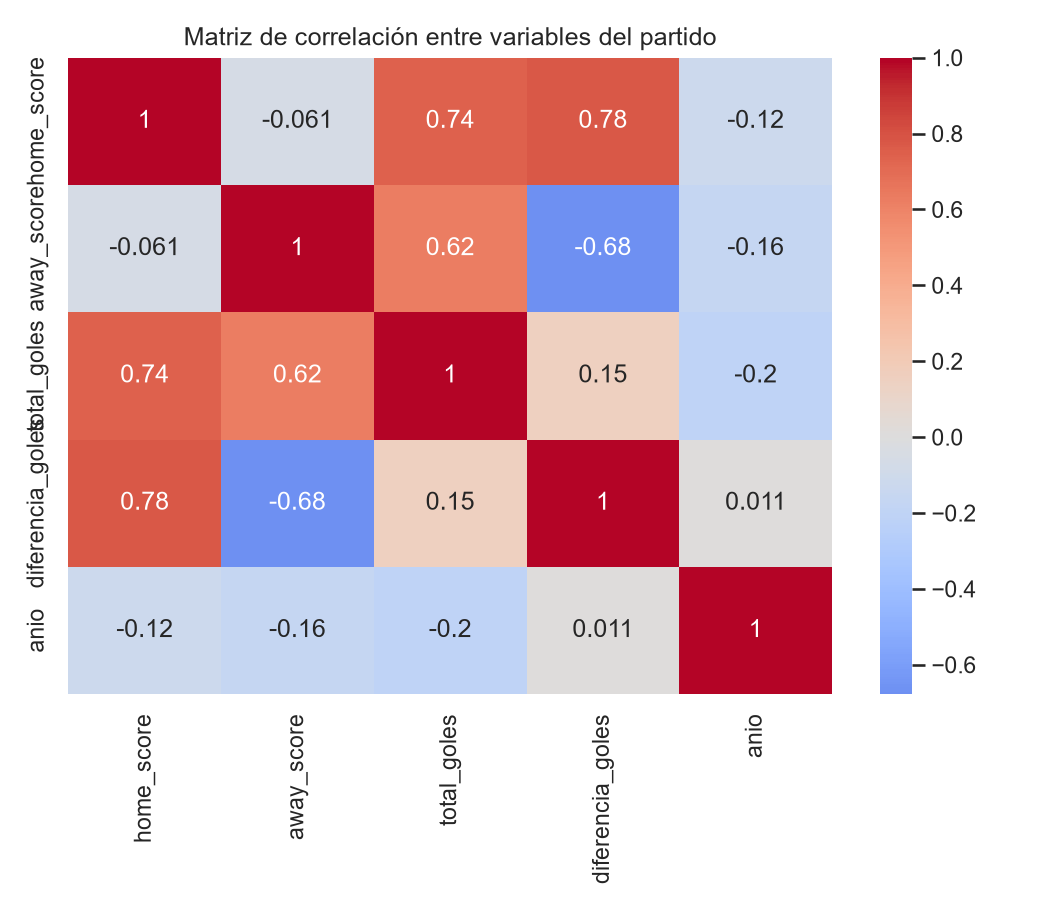

In [14]:
matriz_corr = procesador.matriz_correlacion()
visualizador.heatmap_correlacion(matriz_corr)

Image("../reports/figures/heatmap_correlacion.png")

En este heatmap existe una fuerte correlación entre los goles del local
y la diferencia de goles final (0.78), como es lógico. También destaca
la correlación negativa entre `anio` y `total_goles` (-0.20), lo que
sugiere que los Mundiales recientes tienden a ser ligeramente menos
goleados que los de décadas pasadas

## 6. Marcadores: local vs. visitante

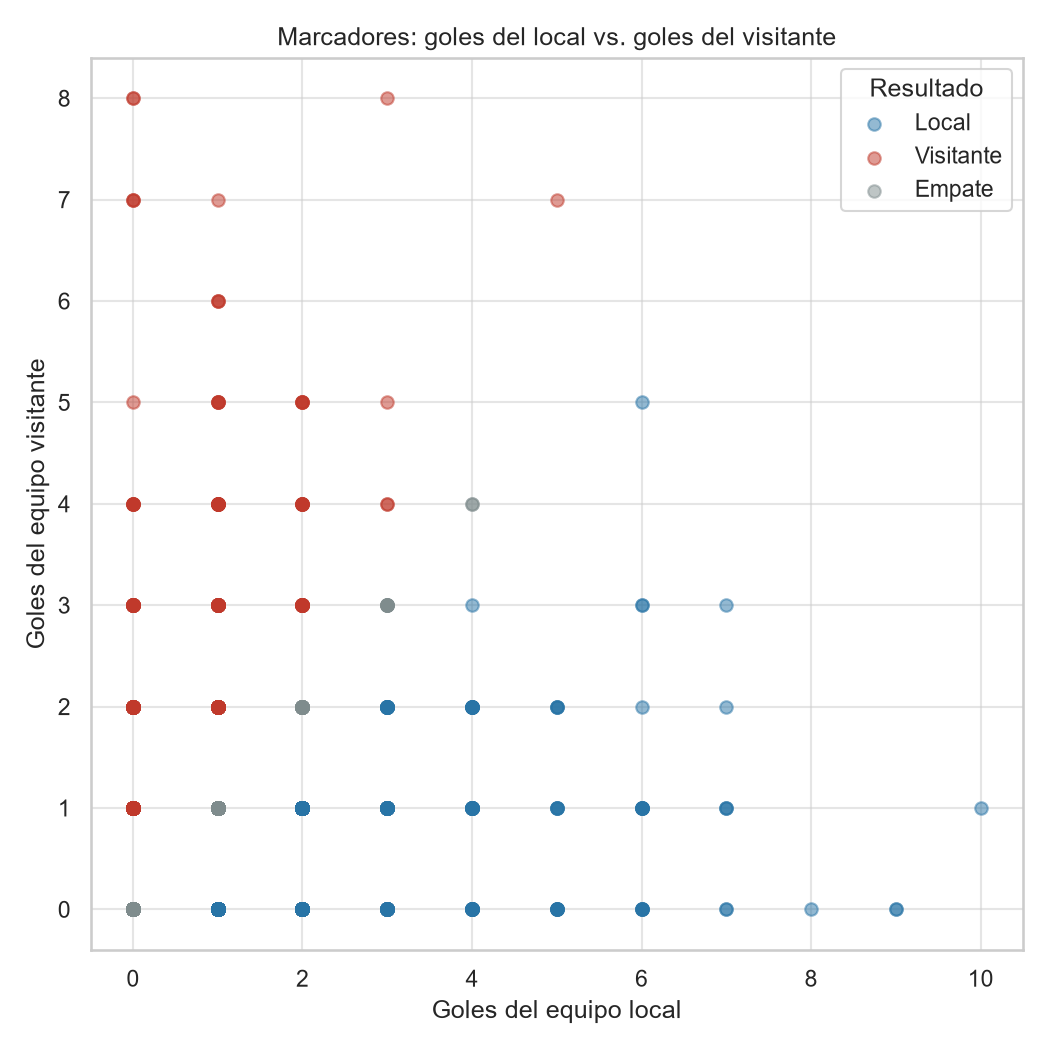

In [15]:
visualizador.scatter_marcadores()

Image("../reports/figures/scatter_marcadores.png")

Ahora en este gráfico se distingue un patrón triangular claro: los puntos azules
(victoria local) quedan por debajo de la diagonal, los rojos (visitante)
por arriba, y los grises (empate) justo sobre ella. La mayor densidad de
puntos está cerca del origen (marcadores bajos como 1-0 o 1-1), y los
marcadores muy altos son escasos, corresponden a las goleadas históricas
que ya vimos con `detectar_outliers_goles()`.

## 7. Países que más veces han sido sede

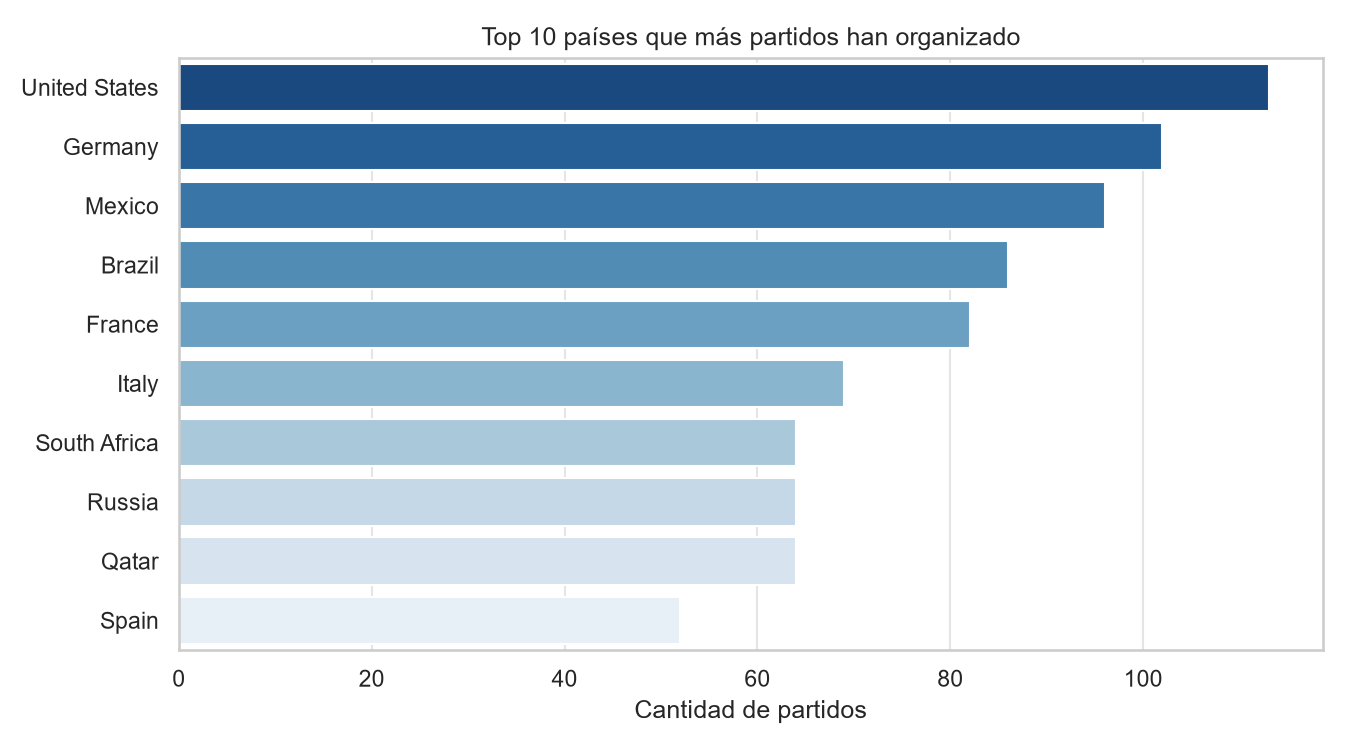

In [16]:
visualizador.partidos_por_pais_sede(top_n=10)

Image("../reports/figures/partidos_por_pais_sede.png")

## Conclusiones

Las visualizaciones confirman los hallazgos principales del EDA:

- Existe una ventaja real para el país anfitrión (62% de victorias
  vs. 43.5% del resto de locales).
- Brasil y Alemania dominan históricamente** en diferencia de goles,
  muy por encima del resto de selecciones.
- La mayoría de partidos mundialistas son de bajo marcador (2-3 goles
  totales), con contadas excepciones históricas como Suiza 7-5 Austria (1954).
- El promedio de goles por partido ha disminuido con el tiempo, desde
  un pico de 5.38 goles/partido en 1954 hasta valores más estables de
  2.2-2.9 en las ediciones modernas.
- Las variables numéricas del partido (goles del local, del visitante,
  diferencia de goles) muestran las correlaciones esperadas, sin
  sorpresas estadísticas.